# GCI World Final Assignment — Reproducible Analysis

**Business proposal:** Proactive churn retention for Company A (telecom).

Run all cells top-to-bottom. Requires `telecom/Client.csv` and `telecom/Record.csv` in the project folder.

| Section | Contents                            |
| ------- | ----------------------------------- |
| 1       | Setup & data loading                |
| 2       | EDA (charts for slides)             |
| 3       | Feature engineering & preprocessing |
| 4       | Models (XGBoost + LightGBM)         |
| 5       | Feature importance                  |
| 6       | Business ROI calculator             |


## 1. Setup & Data Loading


In [1]:
import warnings
import json
import joblib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)

# Resolve paths whether notebook is run from project root or a subfolder
ROOT = Path.cwd()
if not (ROOT / "telecom" / "Client.csv").exists():
    ROOT = ROOT.parent
DATA_DIR = ROOT / "telecom"
FIG_DIR = ROOT / "figures"
MODEL_DIR = ROOT / "Final Assignment" / "models"
FIG_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {ROOT}")

Project root: /home/farout101/Documents/Github/GCI_world/gci-world-final-assignment/Final Assignment


In [2]:
client = pd.read_csv(DATA_DIR / "Client.csv")
record = pd.read_csv(DATA_DIR / "Record.csv")

df = record.merge(client, on="Customer_ID", how="inner")
assert len(df) == 100_000, f"Expected 100k rows, got {len(df)}"

print(f"Merged shape: {df.shape}")
print(f"Churn rate: {df['churn'].mean():.1%}")
df.head(3)

Merged shape: (100000, 100)
Churn rate: 49.6%


,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,change_rev,drop_vce_Mean,drop_dat_Mean,blck_vce_Mean,blck_dat_Mean,unan_vce_Mean,unan_dat_Mean,plcd_vce_Mean,plcd_dat_Mean,recv_vce_Mean,recv_sms_Mean,comp_vce_Mean,comp_dat_Mean,custcare_Mean,ccrndmou_Mean,cc_mou_Mean,inonemin_Mean,threeway_Mean,mou_cvce_Mean,mou_cdat_Mean,mou_rvce_Mean,owylis_vce_Mean,mouowylisv_Mean,iwylis_vce_Mean,mouiwylisv_Mean,peak_vce_Mean,peak_dat_Mean,mou_peav_Mean,mou_pead_Mean,opk_vce_Mean,opk_dat_Mean,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,churn,months,Customer_ID,uniqsubs,actvsubs,new_cell,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,adjqty,avgrev,avgmou,avgqty,avg3mou,avg3qty,avg3rev,avg6mou,avg6qty,avg6rev,prizm_social_one,area,dualband,refurb_new,hnd_price,phones,models,hnd_webcap,truck,rv,ownrent,lor,dwlltype,marital,adults,infobase,income,numbcars,HHstatin,dwllsize,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays
0,23.9975,219.25,22.500,0.2475,0.00,0.0,0.0,0.0,0.0,-157.25,-18.9975,0.666667,0.0,0.666667,0.0,6.333333,0.0,52.333333,0.0,42.333333,0.0,45.000000,0.0,0.000000,0.000000,0.000000,18.000000,0.000000,90.643333,0.0,97.176667,0.000000,0.000000,0.000000,0.000000,58.000000,0.0,132.600000,0.0,24.0,0.0,55.220000,0.0,1.333333,52.333333,45.000000,0.0,0.333333,1,61,1000001,2,1,U,A,N,1652,4228.00000,1504.62,1453.44,4085.00,1602,29.66,83.37,32.69,272,116,30,322.0,136.0,38.0,S,NORTHWEST/ROCKY MOUNTAIN AREA,Y,N,149.98999,2.0,2.0,WCMB,0.0,0.0,O,15.0,S,S,1.0,M,4.0,3.0,C,A,0.0,N,U,U,U,U,U,Y,361.0
1,57.4925,482.75,37.425,0.2475,22.75,9.1,9.1,0.0,0.0,532.25,50.9875,8.333333,0.0,1.000000,0.0,61.333333,0.0,263.333333,0.0,69.000000,0.0,193.333333,0.0,1.666667,6.333333,5.463333,53.000000,0.333333,189.396667,0.0,55.280000,46.333333,24.216667,6.333333,3.696667,83.666667,0.0,75.333333,0.0,157.0,0.0,169.343333,0.0,9.333333,263.333333,193.333333,0.0,5.666667,0,56,1000002,1,1,N,EA,N,14654,26400.00000,2851.68,2833.88,26367.00,14624,51.53,479.40,265.89,305,158,40,477.0,275.0,48.0,U,CHICAGO AREA,N,N,NaN,7.0,6.0,WC,1.0,1.0,NaN,1.0,S,S,1.0,M,5.0,1.0,C,A,0.0,Z,U,U,U,U,U,Y,240.0
2,16.9900,10.25,16.990,0.0000,0.00,0.0,0.0,0.0,0.0,-4.25,0.0000,0.333333,0.0,0.000000,0.0,2.666667,0.0,9.000000,0.0,0.333333,0.0,6.000000,0.0,0.000000,0.000000,0.000000,0.333333,0.000000,5.426667,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.0,5.193333,0.0,1.0,0.0,0.233333,0.0,0.333333,9.000000,6.000000,0.0,0.000000,1,58,1000003,1,1,Y,C,N,7903,24385.05333,2155.91,1934.47,24303.05,7888,34.54,433.98,140.86,12,7,17,11.0,6.0,17.0,S,GREAT LAKES AREA,N,N,29.98999,2.0,1.0,NaN,0.0,0.0,O,7.0,S,M,2.0,M,5.0,2.0,C,A,0.0,N,U,Y,U,U,U,Y,1504.0


## 2. Exploratory Data Analysis

Charts below map directly to slides 5–6 in `slides_outline.md`.


churn
0    50438
1    49562
Name: count, dtype: int64

Churn distribution:
  0: 50,438 (50.4%)
  1: 49,562 (49.6%)


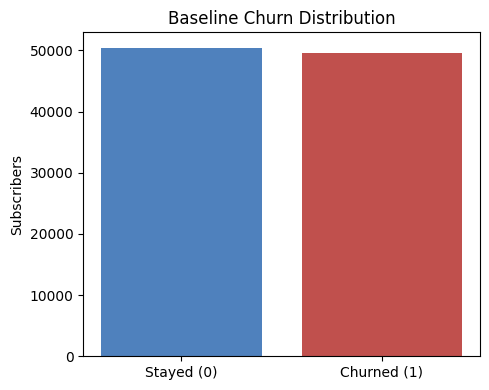

In [3]:
# --- 2a. Target balance ---
churn_counts = df["churn"].value_counts().sort_index()
print(f"{churn_counts}\n")
print("Churn distribution:")
for label, count in churn_counts.items():
    print(f"  {label}: {count:,} ({count / len(df):.1%})")

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["Stayed (0)", "Churned (1)"], churn_counts.values, color=["#4F81BD", "#C0504D"]) # type: ignore
ax.set_ylabel("Subscribers")
ax.set_title("Baseline Churn Distribution")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_churn_distribution.png", dpi=150)
plt.show()

Months 6–10 churn:  33.8%
Months 11–12 churn: 63.7%  (delta: +29.9 pp)


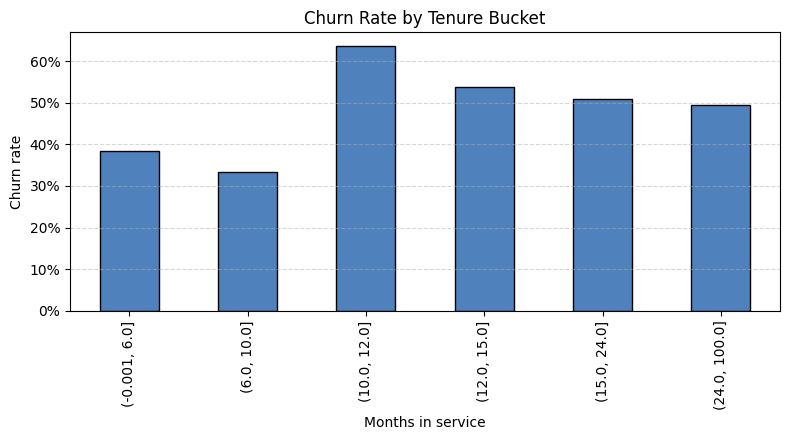

In [4]:
# --- 2b. Contract cliff (tenure) ---
df["months_bucket"] = pd.cut(
    df["months"], bins=[0, 6, 10, 12, 15, 24, 100], include_lowest=True
)
tenure_churn = df.groupby("months_bucket", observed=False)["churn"].mean()

m6_10 = df[(df["months"] >= 6) & (df["months"] <= 10)]["churn"].mean()
m11_12 = df[(df["months"] >= 11) & (df["months"] <= 12)]["churn"].mean()
print(f"Months 6–10 churn:  {m6_10:.1%}")
print(f"Months 11–12 churn: {m11_12:.1%}  (delta: +{(m11_12 - m6_10)*100:.1f} pp)")

fig, ax = plt.subplots(figsize=(8, 4.5))
tenure_churn.plot(kind="bar", ax=ax, color="#4F81BD", edgecolor="black")
ax.set_title("Churn Rate by Tenure Bucket")
ax.set_xlabel("Months in service")
ax.set_ylabel("Churn rate")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}")) # type: ignore
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(FIG_DIR / "02_tenure_churn.png", dpi=150)
plt.show()

Handset <= $50 churn:  57.5%
Handset >  $200 churn: 36.0%
Equipment > 270 days:   54.9%


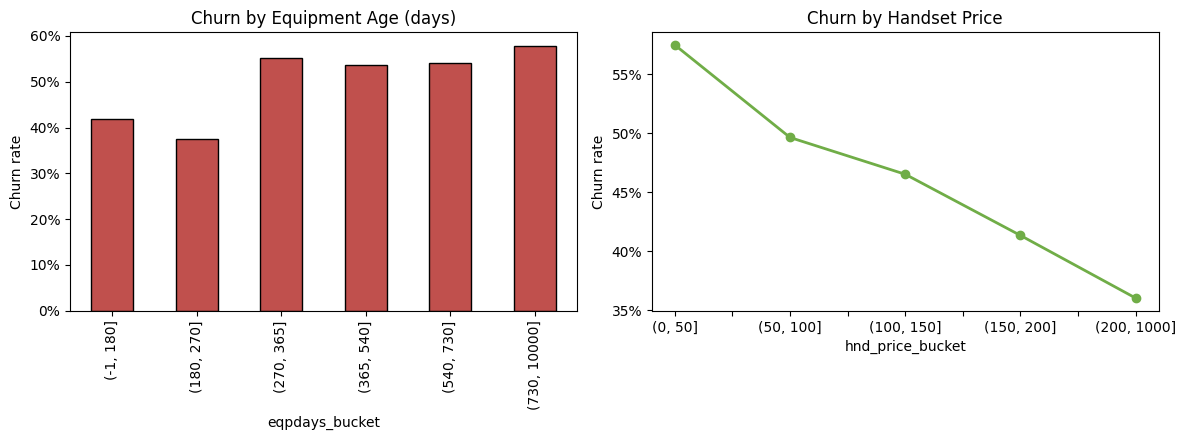

In [5]:
# --- 2c. Equipment age & handset price ---
df["eqpdays_bucket"] = pd.cut(
    df["eqpdays"], bins=[-1, 180, 270, 365, 540, 730, 10_000]
)
eqp_churn = df.groupby("eqpdays_bucket", observed=False)["churn"].mean()

df["hnd_price_bucket"] = pd.cut(
    df["hnd_price"], bins=[0, 50, 100, 150, 200, 1_000]
)
hnd_churn = df.groupby("hnd_price_bucket", observed=False)["churn"].mean()

print(f"Handset <= $50 churn:  {df.loc[df['hnd_price'] <= 50, 'churn'].mean():.1%}")
print(f"Handset >  $200 churn: {df.loc[df['hnd_price'] > 200, 'churn'].mean():.1%}")
print(f"Equipment > 270 days:   {df.loc[df['eqpdays'] > 270, 'churn'].mean():.1%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
eqp_churn.plot(kind="bar", ax=axes[0], color="#C0504D", edgecolor="black")
axes[0].set_title("Churn by Equipment Age (days)")
axes[0].set_ylabel("Churn rate")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}")) # type: ignore

hnd_churn.plot(kind="line", marker="o", ax=axes[1], color="#70AD47", linewidth=2)
axes[1].set_title("Churn by Handset Price")
axes[1].set_ylabel("Churn rate")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}")) # type: ignore

plt.tight_layout()
plt.savefig(FIG_DIR / "03_device_churn.png", dpi=150)
plt.show()

Stayers: change_mou=-5.3, rev_Mean=$59.22/mo
Churners: change_mou=-22.8, rev_Mean=$58.21/mo

Monthly revenue at risk (all churners): $2.87M


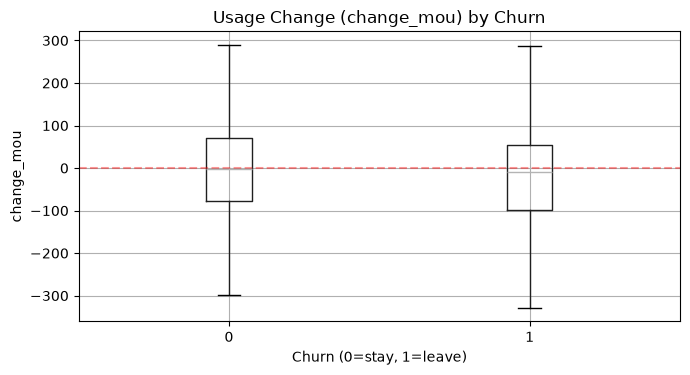

In [3]:
# --- 2d. Usage decline & revenue at risk ---
for churn_val, label in [(0, "Stayers"), (1, "Churners")]:
    subset = df[df["churn"] == churn_val]
    print(
        f"{label}: change_mou={subset['change_mou'].mean():.1f}, "
        f"rev_Mean=${subset['rev_Mean'].mean():.2f}/mo"
    )

monthly_rev_at_risk = df.loc[df["churn"] == 1, "rev_Mean"].sum()
print(f"\nMonthly revenue at risk (all churners): ${monthly_rev_at_risk/1e6:.2f}M")

fig, ax = plt.subplots(figsize=(7, 4))
# Added showfliers=False to solve the scale problem caused by extreme outliers.
# This makes the IQR boxes and medians clearly visible for comparison.
df.boxplot(column="change_mou", by="churn", ax=ax, showfliers=False)

# Add a baseline at zero to highlight the usage decline trend
ax.axhline(0, color='red', linestyle='--', alpha=0.4)

ax.set_title("Usage Change (change_mou) by Churn")
ax.set_xlabel("Churn (0=stay, 1=leave)")
ax.set_ylabel("change_mou")
plt.suptitle("")
plt.tight_layout()
plt.savefig(FIG_DIR / "04_change_mou_by_churn.png", dpi=150)
plt.show()

## 3. Feature Engineering & Preprocessing


In [7]:
# --- Feature engineering (business features) ---
EDA_COLS = ["months_bucket", "eqpdays_bucket", "hnd_price_bucket"]
df_model = df.drop(columns=["Customer_ID"] + EDA_COLS).copy()

df_model["upgrade_eligible"] = (df_model["eqpdays"] >= 270).astype(int)
df_model["bill_shock_risk"] = (df_model["vceovr_Mean"] >= 20.0).astype(int)
df_model["severe_usage_drop"] = (df_model["change_mou"] <= -100.0).astype(int)
df_model["eqp_tenure_ratio"] = df_model["eqpdays"] / (df_model["months"] * 30.0 + 1)
df_model["is_budget_phone"] = (df_model["hnd_price"] <= 50.0).astype(int)
df_model["contract_cliff_window"] = df_model["months"].between(9, 10).astype(int)

# Features / target
X = df_model.drop(columns="churn")
y = df_model["churn"]

# Build an sklearn preprocessing pipeline to avoid data leakage
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ],
    remainder='drop'
)

print(f"Feature matrix X shape: {X.shape}")
print(f"Numeric traits: {len(numeric_cols)} | Categorical traits: {len(categorical_cols)}")
print("Scikit-learn `ColumnTransformer` ready to prevent data leakage during CV & CV.")

Feature matrix X shape: (100000, 104)
Numeric traits: 83 | Categorical traits: 21
Scikit-learn `ColumnTransformer` ready to prevent data leakage during CV & CV.


## 4. Model Training & Evaluation

**Slide requirement:** report model name, metric, and numeric score.


In [ ]:
# --- Stratified split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# --- Define specific model pipelines ---
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        eval_metric='logloss',
        random_state=42,
        use_label_encoder=False,
        n_jobs=-1
    ))
])

lgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LGBMClassifier(
        random_state=42,
        verbose=-1,
        n_jobs=-1
    ))
])

# --- Hyperparameter Grid for Base Models ---
# Limiting range slightly to execute reasonably fast during CV
xgb_param_dist = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.03, 0.08, 0.1]
}

lgb_param_dist = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.03, 0.08, 0.1],
    'classifier__num_leaves': [15, 31, 63]
}

print("Running RandomizedSearchCV (3-fold CV) for LightGBM... (this will take a moment)")
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

lgb_random_search = RandomizedSearchCV(
    lgb_pipeline,
    param_distributions=lgb_param_dist,
    n_iter=5, # Shortened for demonstration/speed
    scoring='roc_auc',
    cv=cv,
    random_state=42,
    n_jobs=-1
)
lgb_random_search.fit(X_train, y_train)
best_lgb_pipe = lgb_random_search.best_estimator_
print(f"Best LGBM Params: {lgb_random_search.best_params_}")

print("Running RandomizedSearchCV for XGBoost...")
xgb_random_search = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=xgb_param_dist,
    n_iter=5,
    scoring='roc_auc',
    cv=cv,
    random_state=42,
    n_jobs=-1
)
xgb_random_search.fit(X_train, y_train)
best_xgb_pipe = xgb_random_search.best_estimator_

# --- Evaluation using the best tuned pipelines ---
xgb_proba = best_xgb_pipe.predict_proba(X_test)[:, 1] # type: ignore
lgb_proba = best_lgb_pipe.predict_proba(X_test)[:, 1] # type: ignore

xgb_pred = (xgb_proba >= 0.5).astype(int)
lgb_pred = (lgb_proba >= 0.5).astype(int)

results = pd.DataFrame({
    "Model": ["XGBoost Classifier (Tuned)", "LightGBM Classifier (Tuned)"],
    "Accuracy": [
        accuracy_score(y_test, xgb_pred),
        accuracy_score(y_test, lgb_pred),
    ],
    "ROC-AUC": [roc_auc_score(y_test, xgb_proba), roc_auc_score(y_test, lgb_proba)],
})

results["Accuracy"] = results["Accuracy"].map(lambda x: f"{x:.1%}")
results["ROC-AUC"] = results["ROC-AUC"].map(lambda x: f"{x:.4f}")

print("\n=== MODEL RESULTS (Copy to Slide 8) ===")
print(results.to_string(index=False))
print("\nSelected model: Tuned LightGBM Classifier")
print(classification_report(y_test, lgb_pred, target_names=["Stay", "Churn"]))

Running RandomizedSearchCV (3-fold CV) for LightGBM... (this will take a moment)
Best LGBM Params: {'classifier__num_leaves': 31, 'classifier__n_estimators': 200, 'classifier__max_depth': 7, 'classifier__learning_rate': 0.03}
Running RandomizedSearchCV for XGBoost...

=== MODEL RESULTS (Copy to Slide 8) ===
                      Model Accuracy ROC-AUC
 XGBoost Classifier (Tuned)    63.9%  0.6924
LightGBM Classifier (Tuned)    63.5%  0.6901

Selected model: Tuned LightGBM Classifier
              precision    recall  f1-score   support

        Stay       0.65      0.61      0.63     15131
       Churn       0.63      0.66      0.64     14869

    accuracy                           0.64     30000
   macro avg       0.64      0.64      0.63     30000
weighted avg       0.64      0.64      0.63     30000



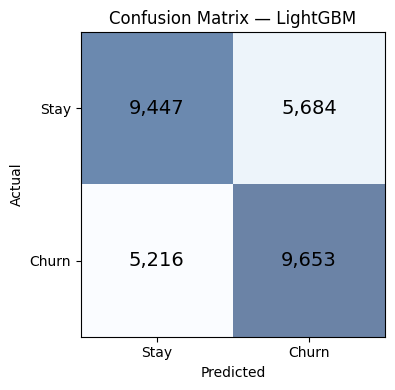

In [ ]:
cm = confusion_matrix(y_test, lgb_pred)

fig, ax = plt.subplots(figsize=(4.5, 4))
ax.imshow(cm, cmap="Blues", alpha=0.6)
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", fontsize=14)
ax.set_xticks([0, 1], labels=["Stay", "Churn"])
ax.set_yticks([0, 1], labels=["Stay", "Churn"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — LightGBM")
plt.tight_layout()
plt.savefig(FIG_DIR / "05_confusion_matrix.png", dpi=150)
plt.show()

## 5. Feature Importance


Top 15 features (LightGBM):
change_mou          458
mou_Mean            382
totmrc_Mean         346
months              308
change_rev          246
avgqty              188
mou_cvce_Mean       165
hnd_price           164
eqpdays             149
eqp_tenure_ratio    146
ovrmou_Mean         128
avgrev              126
uniqsubs            123
drop_vce_Mean       120
lor                 115


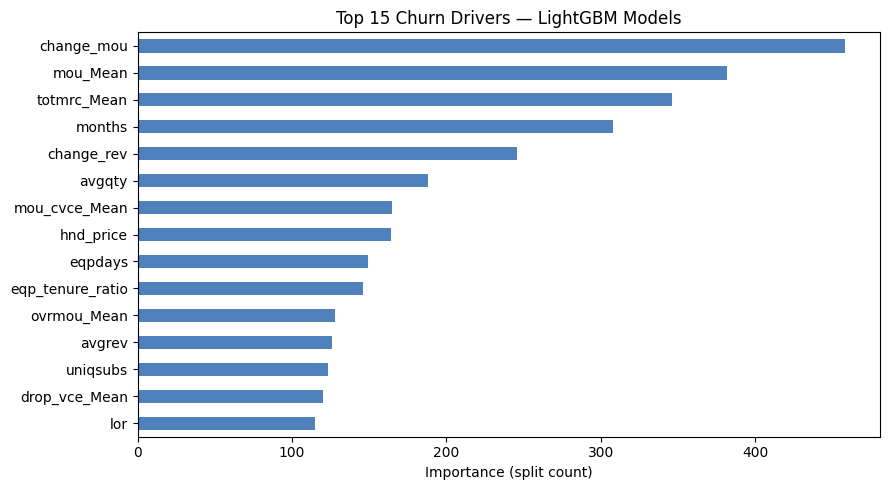

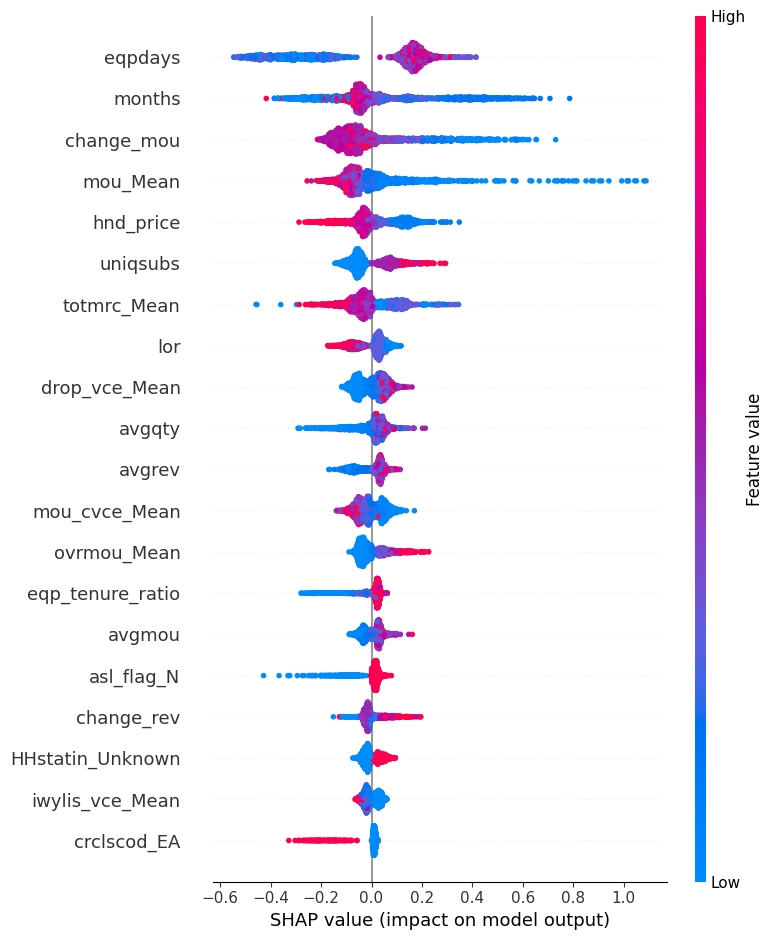

In [ ]:
# --- Determine Feature Names via Preprocessor ---
num_cols = best_lgb_pipe.named_steps['preprocessor'].transformers_[0][2] # type: ignore
cat_cols = best_lgb_pipe.named_steps['preprocessor'].transformers_[1][2] # type: ignore
onehot_maker = best_lgb_pipe.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot'] # type: ignore

onehot_cols = list(onehot_maker.get_feature_names_out(cat_cols)) if hasattr(onehot_maker, 'get_feature_names_out') else []
feature_names = list(num_cols) + onehot_cols

# --- Standard Tree Feature Importances ---
lgb_model = best_lgb_pipe.named_steps['classifier'] # type: ignore
feat_imp = (
    pd.Series(lgb_model.feature_importances_, index=feature_names)
    .sort_values(ascending=False)
    .head(15)
)

print("Top 15 features (LightGBM):")
print(feat_imp.to_string())

fig, ax = plt.subplots(figsize=(9, 5))
feat_imp.sort_values().plot(kind="barh", ax=ax, color="#4F81BD")
ax.set_title("Top 15 Churn Drivers — LightGBM Models")
ax.set_xlabel("Importance (split count)")
plt.tight_layout()
plt.savefig(FIG_DIR / "06_feature_importance.png", dpi=150)
plt.show()

# --- SHAP Val Analysis (Optional robust explainability) ---
# Taking a smaller sample to compute SHAP values quickly 
X_test_transformed = best_lgb_pipe.named_steps['preprocessor'].transform(X_test.sample(2000, random_state=42)) # type: ignore
explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_test_transformed)

# If it's a binary classifier LightGBM might return a list of arrays or a single array
if isinstance(shap_values, list):
    shap_vals = shap_values[1] # Choose positive class
else:
    shap_vals = shap_values

plt.figure(figsize=(10,6))
shap.summary_plot(shap_vals, X_test_transformed, feature_names=feature_names, show=False)
plt.tight_layout()
plt.savefig(FIG_DIR / "07_shap_summary.png", dpi=150)
plt.show()

## 6. Business ROI Calculator

Adjust the parameters below to match your slide assumptions.


In [ ]:
def roi_case(
    n_targeted: int,
    subsidy_usd: float,
    acceptance_rate: float,
    precision: float,
    monthly_arpu: float,
) -> dict:
    """Conservative retention campaign ROI."""
    campaign_cost = n_targeted * subsidy_usd
    customers_saved = n_targeted * acceptance_rate * precision
    annual_rev_protected = customers_saved * monthly_arpu * 12
    net = annual_rev_protected - campaign_cost
    return {
        "targeted": n_targeted,
        "campaign_cost_usd": campaign_cost,
        "customers_saved": customers_saved,
        "annual_rev_protected_usd": annual_rev_protected,
        "net_usd": net,
    }

# Compute the optimal Precision to map back into ROI
# Typically precision drops as we lower our prediction threshold.
# Let's say we pick the top decile where threshold >= 0.65
threshold = 0.65
y_pred_high_threshold = (lgb_proba >= threshold).astype(int)

# Real precision at this threshold 
from sklearn.metrics import precision_score
real_precision = precision_score(y_test, y_pred_high_threshold)

avg_monthly_arpu = df["rev_Mean"].mean()
high_value_arpu = df.loc[df["rev_Mean"] >= df["rev_Mean"].quantile(0.8), "rev_Mean"].mean()

base = roi_case(
    n_targeted=10_000,
    subsidy_usd=100,
    acceptance_rate=0.20,
    precision=real_precision, # type: ignore
    monthly_arpu=avg_monthly_arpu,
)
high_value = roi_case(
    n_targeted=10_000,
    subsidy_usd=100,
    acceptance_rate=0.20,
    precision=real_precision, # type: ignore
    monthly_arpu=high_value_arpu,
)

print("=== ROI SCENARIOS (copy to Slide 12) ===")
print(f"Optimal Probability Threshold Chosen: >={threshold}")
print(f"Model Precision at threshold: {real_precision:.1%}")
print(f"Average monthly ARPU: ${avg_monthly_arpu:.2f}")
print(f"Top-20% monthly ARPU: ${high_value_arpu:.2f}")
print()
for name, case in [("Base (avg ARPU)", base), ("High-value segment", high_value)]:
    print(name)
    for k, v in case.items():
        if "usd" in k:
            print(f"  {k}: ${v:,.0f}")
        elif k == "customers_saved":
            print(f"  {k}: {v:,.0f}")
        else:
            print(f"  {k}: {v:,}")
    print()

=== ROI SCENARIOS (copy to Slide 12) ===
Optimal Probability Threshold Chosen: >=0.65
Model Precision at threshold: 75.6%
Average monthly ARPU: $58.72
Top-20% monthly ARPU: $123.82

Base (avg ARPU)
  targeted: 10,000
  campaign_cost_usd: $1,000,000
  customers_saved: 1,512
  annual_rev_protected_usd: $1,065,215
  net_usd: $65,215

High-value segment
  targeted: 10,000
  campaign_cost_usd: $1,000,000
  customers_saved: 1,512
  annual_rev_protected_usd: $2,246,222
  net_usd: $1,246,222



In [ ]:
# --- Model Saving & Documentation ---
# Export model artifacts to avoid retraining during presentation.
import joblib
joblib.dump(best_lgb_pipe, MODEL_DIR / "lgbm_tuned_pipeline.pkl")
joblib.dump(best_xgb_pipe, MODEL_DIR / "xgb_tuned_pipeline.pkl")
print(f"Saved tuned model artifacts to {MODEL_DIR}")